# Online Retail Store Analysis

## Preparing environment

### Loading up needed modules

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from pathlib import Path

### Importing data

In [63]:
df = pd.read_csv(Path("datasets") / "online_retail.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [64]:
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
102967,545045,22096,PINK PAISLEY SQUARE TISSUE BOX,1,2011-02-27 11:40:00,1.25,15708.0,United Kingdom
513220,579540,21930,JUMBO STORAGE BAG SKULLS,10,2011-11-30 10:11:00,2.08,13658.0,United Kingdom
201874,C554336,23126,FELTCRAFT GIRL AMELIE KIT,-1,2011-05-23 17:20:00,4.95,12474.0,Germany
264569,560104,22178,VICTORIAN GLASS HANGING T-LIGHT,18,2011-07-14 18:56:00,1.25,17921.0,United Kingdom
486778,577748,23102,SILVER HEARTS TABLE DECORATION,12,2011-11-21 14:24:00,0.83,15159.0,United Kingdom
428451,573430,22333,RETROSPOT PARTY BAG + STICKER SET,8,2011-10-31 10:38:00,1.65,13813.0,Germany
388407,570428,23351,ROLL WRAP 50'S CHRISTMAS,2,2011-10-10 14:02:00,1.25,15553.0,United Kingdom
373460,569331,23528,SPACEBOY WALL ART,6,2011-10-03 13:39:00,3.75,16875.0,United Kingdom
308576,564037,23230,WRAP ALPHABET DESIGN,25,2011-08-22 12:26:00,0.42,14800.0,United Kingdom
518427,580115,22965,3 TRADITIONAl BISCUIT CUTTERS SET,1,2011-12-01 16:22:00,4.13,NaN,United Kingdom


# Data preparation

## Checking column completeness

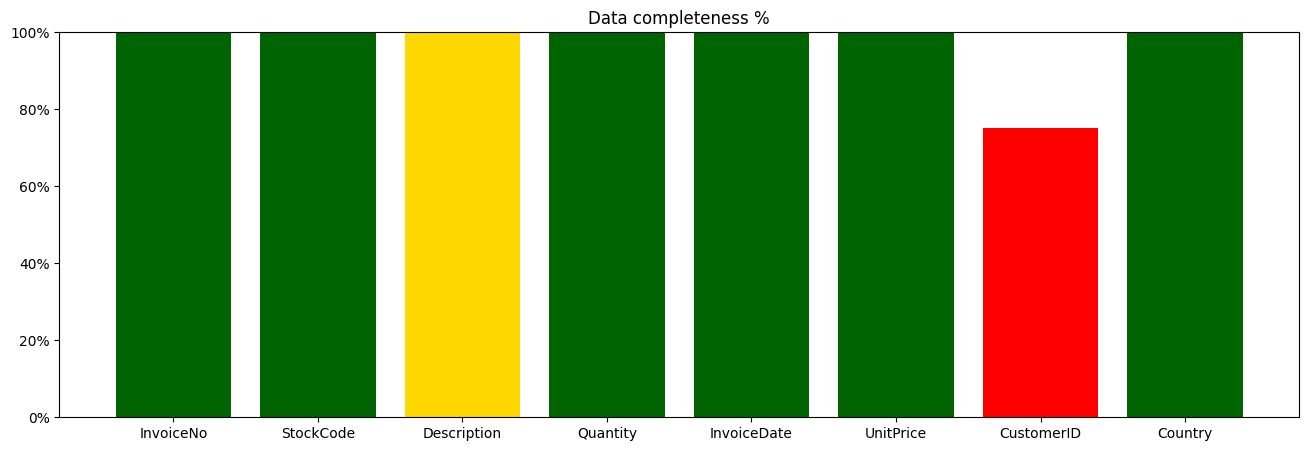

In [65]:
all_cols = df.columns
bar_colors = []
counted_cols = []
for col_name in all_cols:
    completeness = 1 - len(df.loc[df[col_name].isnull(), col_name]) / len(df)
    counted_cols.append(completeness)
    if completeness == 1.0:
        bar_colors.append("darkgreen")
    elif completeness > 0.8:
        bar_colors.append("gold")
    else:
        bar_colors.append("red")


def percentage_format(x, position):
    return f"{round(x * 100)}%"


fig, axs = plt.subplots(figsize=(len(counted_cols) * 2, 5))
axs.set_title("Data completeness %")
axs.yaxis.set_major_formatter(percentage_format)
axs.bar(all_cols, counted_cols, color=bar_colors)
axs.set_ylim(0, 1)
plt.show()

### Missing Customer Data

As we can see, the dataset lacks `CustomerID` for many records. By dropping these rows, this analysis excludes "guest checkouts". Our focus is strictly on registered users, allowing for a genuine evaluation of customer loyalty, retention metrics, and long-term user behavior.

### Data Architecture: Splitting the Dataset

To ensure absolute metric accuracy, we must branch our dataset based on the business question being asked:

1. **Net Revenue & LTV (Full Dataset):** The original dataset includes invoices starting with "C" (cancellations and returns). These are crucial for calculating true Net Lifetime Value (LTV), as returns offset gross revenue.
2. **Cohort Retention (Filtered Dataset):** For analyzing user loyalty, we create a separate `df_no_cancel` dataframe excluding cancellations. If we kept returns here, our grouping logic would register a product return in a subsequent month as a new "active shopping session," artificially inflating our retention rates.

In [66]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [67]:
df_no_cancel = df.dropna(subset="CustomerID")

# Removing cancelled invoices and returned products
df_no_cancel = df_no_cancel[~df_no_cancel["InvoiceNo"].str.startswith("C")]
df_no_cancel = df_no_cancel[
    (df_no_cancel["Quantity"] > 0) & (df_no_cancel["UnitPrice"] > 0)
]
df_no_cancel.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Cohort retention analysis

Here I am assigning new columns to the retention data frame:
- `InvoiceMonth` is as the name says - month an invoice was issued.
- `CohortMonth` is based on the newly created `InvoiceMonth` column - it assigns every customer to the first month they made a purchase in our store.
- `CohortIndex` is the difference in months between the first purchase and later purchases.

In [68]:
df_retention = df_no_cancel.assign(
    InvoiceMonth=lambda x: x["InvoiceDate"].values.astype("datetime64[M]"),
    CohortMonth=lambda x: x.groupby("CustomerID")["InvoiceMonth"].transform("min"),
    CohortIndex=lambda x: (
        (x["InvoiceMonth"].dt.year - x["CohortMonth"].dt.year) * 12
        + (x["InvoiceMonth"].dt.month - x["CohortMonth"].dt.month)
    ),
)
df_retention.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth,CohortMonth,CohortIndex
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010-12-01,2010-12-01,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010-12-01,2010-12-01,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010-12-01,2010-12-01,0


Group by cohort months (First purchases of customers)

In [69]:
cohort_data = (
    df_retention.groupby(["CohortMonth", "CohortIndex"])
    .agg({"CustomerID": "nunique"})
    .reset_index()
)
cohort_data

,CohortMonth,CohortIndex,CustomerID
0,2010-12-01,0,885
1,2010-12-01,1,324
2,2010-12-01,2,286
3,2010-12-01,3,340
4,2010-12-01,4,321
...,...,...,...
86,2011-10-01,1,86
87,2011-10-01,2,41
88,2011-11-01,0,323
89,2011-11-01,1,36


Creating the table

In [70]:
cohort_table = pd.pivot(
    cohort_data, columns="CohortIndex", values="CustomerID", index="CohortMonth"
)
cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02-01,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03-01,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04-01,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05-01,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06-01,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Creating the heatmap using Seaborn

Basic heatmap already shows some interesing information - last year's December attracted almost twice as many customers as any other month later on.

However, the current heatmap isn't very readable. Better approach to showing customer retention would be to use percentage instead of raw numbers.

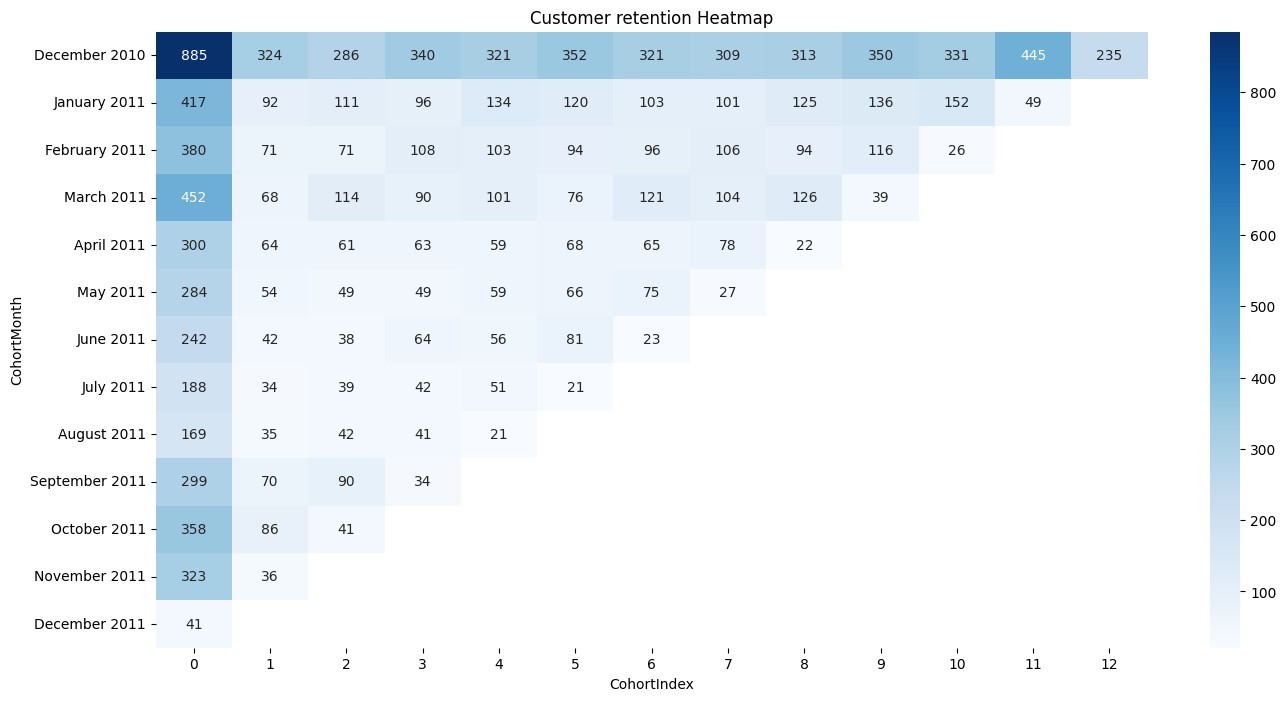

In [71]:
y_labels = cohort_table.index.strftime("%B %Y")

plt.figure(figsize=(16, 8))
sns.heatmap(cohort_table, cmap="Blues", yticklabels=y_labels, fmt="g", annot=True)
plt.title("Customer retention Heatmap")
plt.show()

#### Improving heatmap readability
Here I am dividing whole rows by the first element of each. This way I can measure retention in percentage of consumers who stayed.

In [72]:
cohort_table_ratio = cohort_table.divide(cohort_table.iloc[:, 0], axis=0)
cohort_table_ratio

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12-01,1.0,0.366102,0.323164,0.384181,0.362712,0.397740,0.362712,0.349153,0.353672,0.395480,0.374011,0.502825,0.265537
2011-01-01,1.0,0.220624,0.266187,0.230216,0.321343,0.287770,0.247002,0.242206,0.299760,0.326139,0.364508,0.117506,NaN
2011-02-01,1.0,0.186842,0.186842,0.284211,0.271053,0.247368,0.252632,0.278947,0.247368,0.305263,0.068421,NaN,NaN
2011-03-01,1.0,0.150442,0.252212,0.199115,0.223451,0.168142,0.267699,0.230088,0.278761,0.086283,NaN,NaN,NaN
2011-04-01,1.0,0.213333,0.203333,0.210000,0.196667,0.226667,0.216667,0.260000,0.073333,NaN,NaN,NaN,NaN
2011-05-01,1.0,0.190141,0.172535,0.172535,0.207746,0.232394,0.264085,0.095070,NaN,NaN,NaN,NaN,NaN
2011-06-01,1.0,0.173554,0.157025,0.264463,0.231405,0.334711,0.095041,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,1.0,0.180851,0.207447,0.223404,0.271277,0.111702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,1.0,0.207101,0.248521,0.242604,0.124260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Readable heatmap
The heatmap now is much more readable, but now we lost the key information of an absolute number of customers acquired that month.

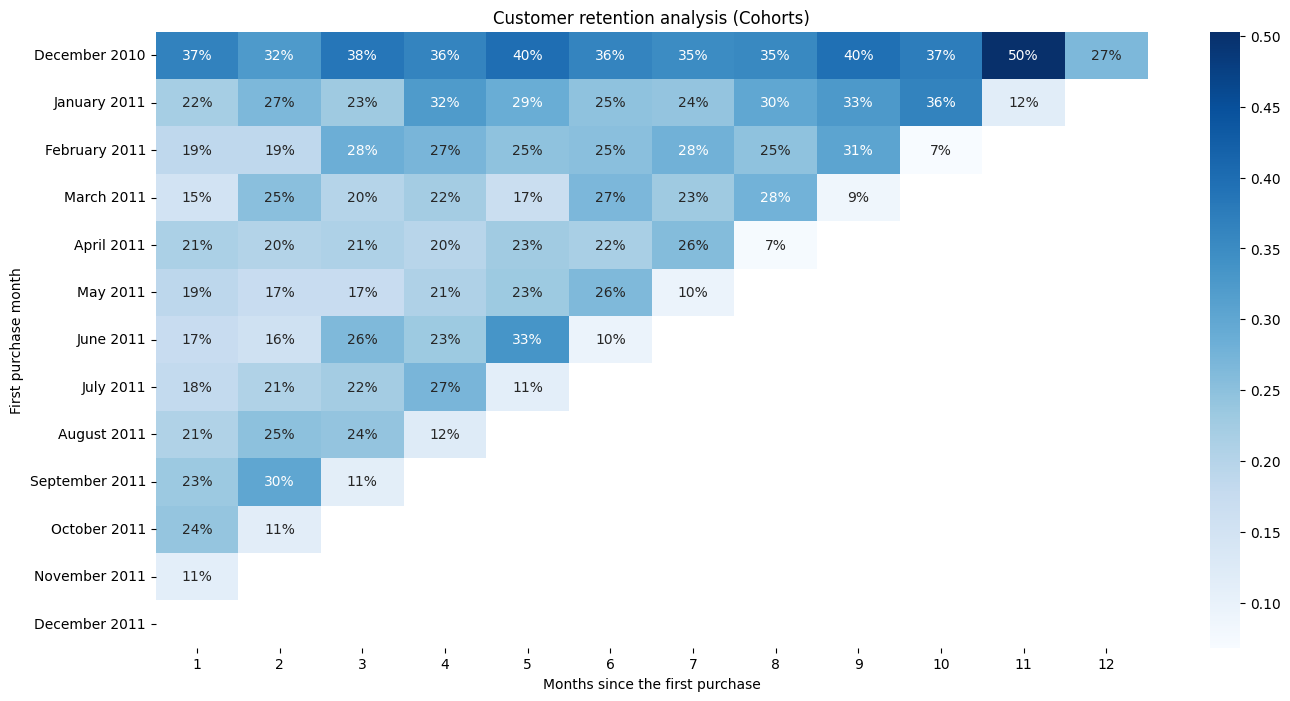

In [73]:
y_labels = cohort_table_ratio.index.strftime("%B %Y")
plt.figure(figsize=(16, 8))
sns.heatmap(
    cohort_table_ratio.iloc[:, 1:],
    cmap="Blues",
    yticklabels=y_labels,
    annot=True,
    fmt=".0%",
)
plt.ylabel("First purchase month")
plt.xlabel("Months since the first purchase")
plt.title("Customer retention analysis (Cohorts)")
plt.show()

#### Adding the cohort size
To address that problem we need to create a subplot in which the absolute number of customers would be visible.

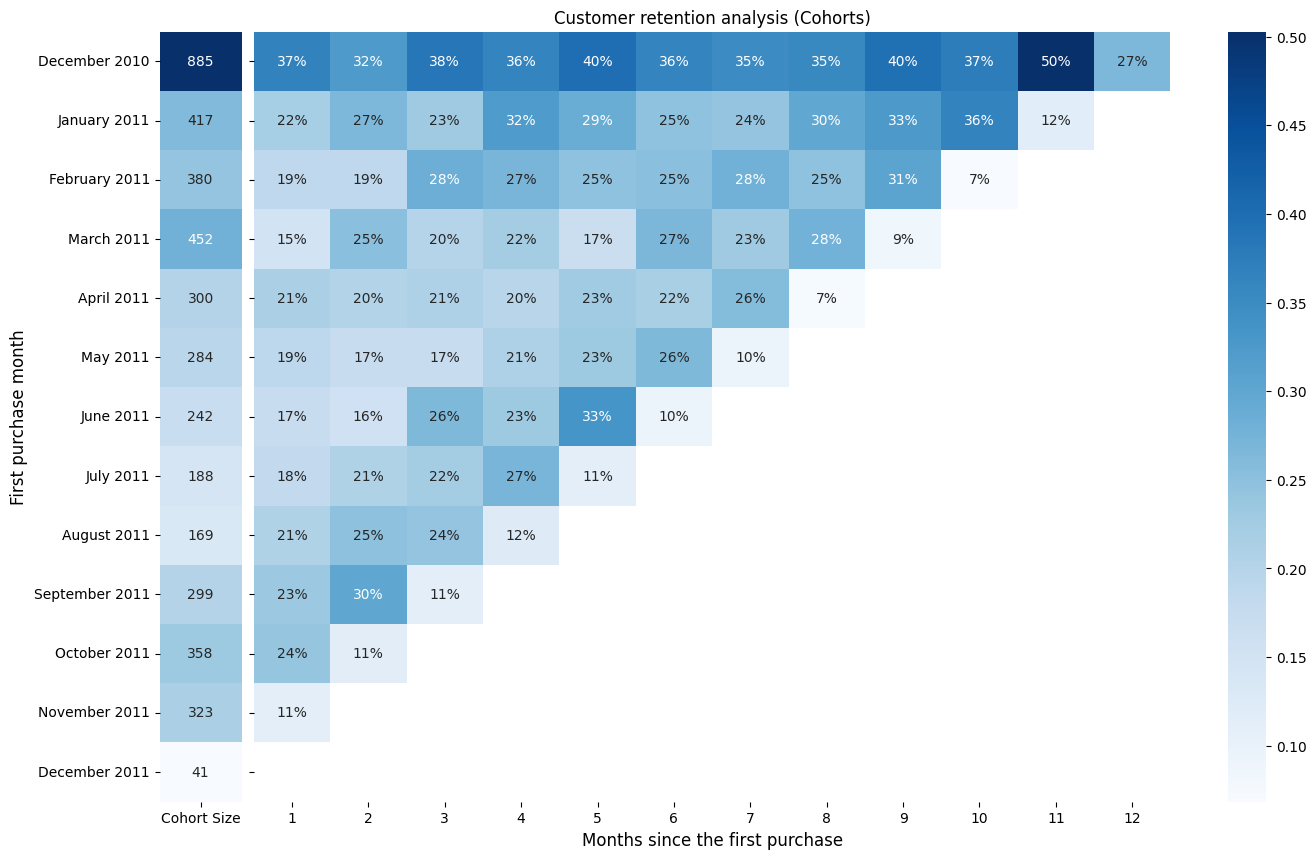

In [74]:
cohort_size = (
    df_retention.groupby("CohortMonth")
    .agg({"CustomerID": "nunique"})
    .rename(columns={"CustomerID": "Cohort Size"})
)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 10), sharey=True, gridspec_kw={"width_ratios": [1, 14]}
)
sns.heatmap(cohort_size, cbar=False, cmap="Blues", annot=True, fmt="g", ax=ax1)
sns.heatmap(
    cohort_table_ratio.iloc[:, 1:],
    cmap="Blues",
    annot=True,
    fmt=".0%",
    ax=ax2,
    yticklabels=y_labels,
)
plt.subplots_adjust(wspace=0.02)
ax1.set_ylabel("First purchase month", fontsize=12)
ax2.set_ylabel("")
ax2.set_xlabel("Months since the first purchase", fontsize=12)
ax2.set_title("Customer retention analysis (Cohorts)")
plt.show()

### Executive Summary & Business Recommendations

#### Missing Data & Cohort Bias
* **Observation:** The great results of the December 2010 cohort are affected by missing past data. Because our dataset starts in this month, this group probably contains many old, loyal customers, not just the new ones. The sudden drop in December 2011 is also caused by incomplete data for that month.
* **Recommendation:** To correctly measure customer retention, we need to get historical data from before December 2010. This will help us separate the real "new" customers from the "existing" ones.

#### Seasonality & Marketing Budget
* **Observation:** There is a clear drop in new customer acquisition and their loyalty during the summer months. On the other hand, the Fall season (September-November) shows strong acquisition and high retention rates.
* **Recommendation:** The marketing department should adjust its budget. We should spend less money during the weak summer months and move this budget to September and October. This will help build a strong customer base before the winter holidays.

#### The "November Comeback"
* **Observation:** A diagonal pattern on the retention matrix shows that many inactive customers from previous months came back in November 2011. This was probably driven by Black Friday and early Christmas shopping.
* **Recommendation:** We should take advantage of this predictable trend. Product and Marketing teams should plan automated "win-back" email campaigns for inactive customers from Spring and Summer.


## RFM Analysis

In [84]:
df_monetary = (
    df.assign(TotalPrice=lambda x: x["UnitPrice"] * x["Quantity"])
    .groupby("CustomerID")
    .agg(Monetary=("TotalPrice", "sum"))
)

ref_date = df_no_cancel["InvoiceDate"].max() + pd.Timedelta(days=1)
df_rf = (
    df_no_cancel.assign(
        RecencyDays=lambda x: (ref_date - x["InvoiceDate"]).dt.days,
    )
    .groupby("CustomerID")
    .agg(Recency=("RecencyDays", "min"), Frequency=("InvoiceNo", "nunique"))
)
df_rfm = df_rf.join(df_monetary)
df_rfm = df_rfm.set_index(df_rfm.index.astype("int64"))
df_rfm = df_rfm.loc[df_rfm["Monetary"] > 0].copy()
df_rfm.describe().round(2)
df_rfm

,Recency,Frequency,Monetary
CustomerID,,,
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40
12352,36,8,1545.41
...,...,...,...
18280,278,1,180.60
18281,181,1,80.82
18282,8,2,176.60


Assign points to customers

In [ ]:
labels = [1, 2, 3, 4, 5]
labels_reversed = labels.copy()
labels_reversed.reverse()

rfm_score = df_rfm.sort_values(by=["Monetary", "Frequency"], ascending=[True, True]).assign(
    RecScore=lambda x: pd.qcut(
        x["Recency"].rank(method="first"), q=5, labels=labels_reversed
    ),
    FreqScore=lambda x: pd.qcut(
        x["Frequency"].rank(method="first"), q=5, labels=labels
    ),
    MonScore=lambda x: pd.qcut(x["Monetary"].rank(method="first"), q=5, labels=labels),
    RFMScore=lambda x: x['RecScore'].astype('str') + "-" + x['FreqScore'].astype('str') + "-" + x['MonScore'].astype('str')
)
rfm_score


,Recency,Frequency,Monetary,RecScore,FreqScore,MonScore,RFMScore
CustomerID,,,,,,,
18274,30,1,1.776357e-15,4,1,1,4-1-1
12607,60,1,3.552714e-15,3,1,1,3-1-1
13762,219,1,3.552714e-15,1,1,1,1-1-1
12558,8,1,1.065814e-14,5,1,1,5-1-1
12454,56,1,5.684342e-14,3,1,1,3-1-1
...,...,...,...,...,...,...,...
12415,24,21,1.237254e+05,4,5,5,4-5-5
14911,1,201,1.325726e+05,5,5,5,5-5-5
17450,8,46,1.874822e+05,5,5,5,5-5-5


Pareto rule in gross revenue per customer

In [ ]:
df_pareto = (
    df.groupby("CustomerID")
    .agg({"TotalPrice": "sum"})
    .sort_values(by=["TotalPrice"], ascending=False)
    .reset_index()
)
n = 1
df_pareto["CumSum"] = df_pareto["TotalPrice"].cumsum()
total_revenue = df_pareto["TotalPrice"].sum()
df_pareto["RevenuePercent"] = df_pareto["CumSum"] / total_revenue
top_80_revenue = df_pareto[df_pareto["RevenuePercent"] <= 0.80]
top_count = len(top_80_revenue)
total_count = len(df_pareto)
ratio = top_count / total_count
f"80% of revenue is generated by top {ratio:.1%} customers"

'80% of revenue is generated by top 26.1% customers'

Hourly buying time in span of a week

Golden hour is at 12:00. The best day is Wednesday with 611 purchases at 12:00


hour,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
day,,,,,,,,,,,,,,,
Monday,0,4,85,251,322,340,480,436,374,317,184,70,0,0,0
Tuesday,0,5,115,290,393,405,531,475,371,345,163,88,3,0,0
Wednesday,0,5,116,290,434,413,611,493,417,371,223,79,0,2,1
Thursday,1,9,119,294,442,370,586,479,445,421,309,245,164,133,16
Friday,0,6,120,266,410,364,463,397,361,253,115,62,2,9,1
Saturday,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Sunday,0,0,0,2,225,385,459,356,306,330,106,0,0,0,0


Text(0.5, 58.7222222222222, 'Hour of purchase')

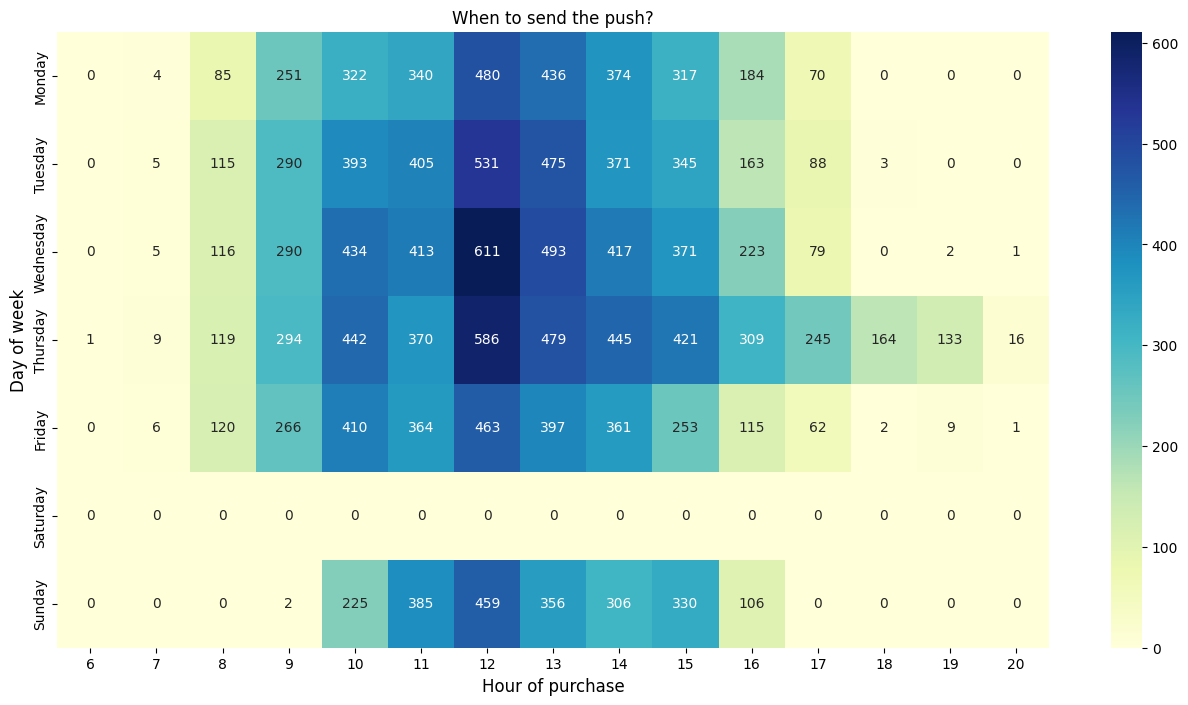

In [ ]:
days_dict = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}
days_order = [0, 1, 2, 3, 4, 5, 6]
df["day"] = df["InvoiceDate"].dt.day_of_week
df["hour"] = df["InvoiceDate"].dt.hour
purchase_time = df.groupby(["day", "hour"]).agg({"InvoiceNo": "nunique"}).reset_index()
purchase_matrix = (
    purchase_time.pivot(index="day", columns="hour", values="InvoiceNo")
    .reindex(days_order)
    .rename(index=days_dict)
    .fillna(0)
    .astype("int64")
)
golden_hour = purchase_matrix.stack().idxmax()
number_of_purchases = purchase_matrix.max().max()
print(
    f"Golden hour is at {golden_hour[1]}:00. The best day is {golden_hour[0]} with {number_of_purchases} purchases at {golden_hour[1]}:00"
)
display(purchase_matrix)

plt.figure(figsize=(16, 8))
sns.heatmap(purchase_matrix, annot=True, cmap="YlGnBu", fmt="g")
plt.title("When to send the push?")
plt.ylabel("Day of week", fontsize=12)
plt.xlabel("Hour of purchase", fontsize=12)

Products bought in pairs

In [ ]:
product_map = df[["StockCode", "Description"]].drop_duplicates(
    subset=["StockCode"], keep="first"
)
df_pairs = df[["InvoiceNo", "StockCode"]]
df_pairs = df_pairs.merge(df_pairs, on="InvoiceNo", suffixes=("_A", "_B"))
df_pairs

,InvoiceNo,StockCode_A,StockCode_B
0,536365,85123A,85123A
1,536365,85123A,71053
2,536365,85123A,84406B
3,536365,85123A,84029G
4,536365,85123A,84029E
...,...,...,...
20050583,581587,22138,22613
20050584,581587,22138,22899
20050585,581587,22138,23254
20050586,581587,22138,23255


In [ ]:
df_pairs = df_pairs[df_pairs["StockCode_A"] < df_pairs["StockCode_B"]]
df_pairs = (
    df_pairs.groupby(
        [
            "StockCode_A",
            "StockCode_B",
        ]
    )
    .agg({"StockCode_B": "count"})
    .rename(columns={"StockCode_B": "Count"})
    .reset_index()
)

In [ ]:
df_pairs_pretty = (
    df_pairs.merge(product_map, left_on="StockCode_A", right_on="StockCode")
    .drop(columns="StockCode")
    .rename(columns={"Description": "Description_A"})
)
df_pairs_pretty = (
    df_pairs_pretty.merge(product_map, left_on="StockCode_B", right_on="StockCode")
    .drop(columns="StockCode")
    .rename(columns={"Description": "Description_B"})
)
df_pairs_pretty = df_pairs_pretty[
    ["StockCode_A", "Description_A", "StockCode_B", "Description_B", "Count"]
].sort_values(by="Count", ascending=False)
df_pairs_pretty.head(20)

,StockCode_A,Description_A,StockCode_B,Description_B,Count
1668426,22697,GREEN REGENCY TEACUP AND SAUCER,22698,PINK REGENCY TEACUP AND SAUCER,721
1668427,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,618
1376427,22386,JUMBO BAG PINK POLKADOT,85099B,JUMBO BAG RED RETROSPOT,579
1692724,22726,ALARM CLOCK BAKELIKE GREEN,22727,ALARM CLOCK BAKELIKE RED,579
161684,20725,LUNCH BAG RED RETROSPOT,20727,LUNCH BAG BLACK SKULL.,571
162650,20725,LUNCH BAG RED RETROSPOT,22384,LUNCH BAG PINK POLKADOT,562
162649,20725,LUNCH BAG RED RETROSPOT,22383,LUNCH BAG SUKI DESIGN,557
167968,20727,LUNCH BAG BLACK SKULL.,22383,LUNCH BAG SUKI DESIGN,523
1669823,22698,PINK REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,515
167969,20727,LUNCH BAG BLACK SKULL.,22384,LUNCH BAG PINK POLKADOT,511


Top Countries by average revenue per user

In [ ]:
arpu_summary = (
    df[df["Country"] != "United Kingdom"]
    .groupby(["Country", "CustomerID"])
    .agg({"TotalPrice": "sum"})
    .reset_index()
    .groupby("Country")
    .filter(lambda x: len(x) >= 20)
    .groupby("Country")
    .agg({"CustomerID": "nunique", "TotalPrice": "mean"})
    .rename(columns={"TotalPrice": "ARPU", "CustomerID": "Customers"})
)
arpu_summary

,Customers,ARPU
Country,,
Belgium,25,1647.853600
France,87,2402.575287
Germany,94,2434.756809
Spain,30,2052.570333
Switzerland,21,2687.807143


Median spending per Cohort month

In [ ]:
ltv = df.groupby(["CohortMonth", "CustomerID"]).agg({"TotalPrice": "sum"}).reset_index()
ltv.groupby("CohortMonth").agg(MedianSpending=("TotalPrice", "median"))

,MedianSpending
CohortMonth,
2010-12-01,1661.060
2011-01-01,1161.530
2011-02-01,899.410
2011-03-01,708.535
2011-04-01,673.615
2011-05-01,626.880
2011-06-01,508.045
2011-07-01,500.780
2011-08-01,531.350


Churn analysis

In [ ]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
customer_last_purchase = df.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max")
)
customer_last_purchase["Recency"] = (
    reference_date - customer_last_purchase["LastPurchase"]
).dt.days
customer_last_purchase["Status"] = np.where(
    customer_last_purchase["Recency"] < 90, "Active", "Churned"
)
customer_last_purchase.index = customer_last_purchase.index.astype("int64")
display(
    customer_last_purchase["Status"].value_counts(normalize=True),
    customer_last_purchase,
)

Status
Active     0.6639
Churned    0.3361
Name: proportion, dtype: float64

,LastPurchase,Recency,Status
CustomerID,,,
12346,2011-01-18 10:01:00,326,Churned
12347,2011-12-07 15:52:00,2,Active
12348,2011-09-25 13:13:00,75,Active
12349,2011-11-21 09:51:00,19,Active
12350,2011-02-02 16:01:00,310,Churned
...,...,...,...
18280,2011-03-07 09:52:00,278,Churned
18281,2011-06-12 10:53:00,181,Churned
18282,2011-12-02 11:43:00,8,Active


Median monthly spend per customer

Text(0.5, 80.7222222222222, 'Months since the first purchase')

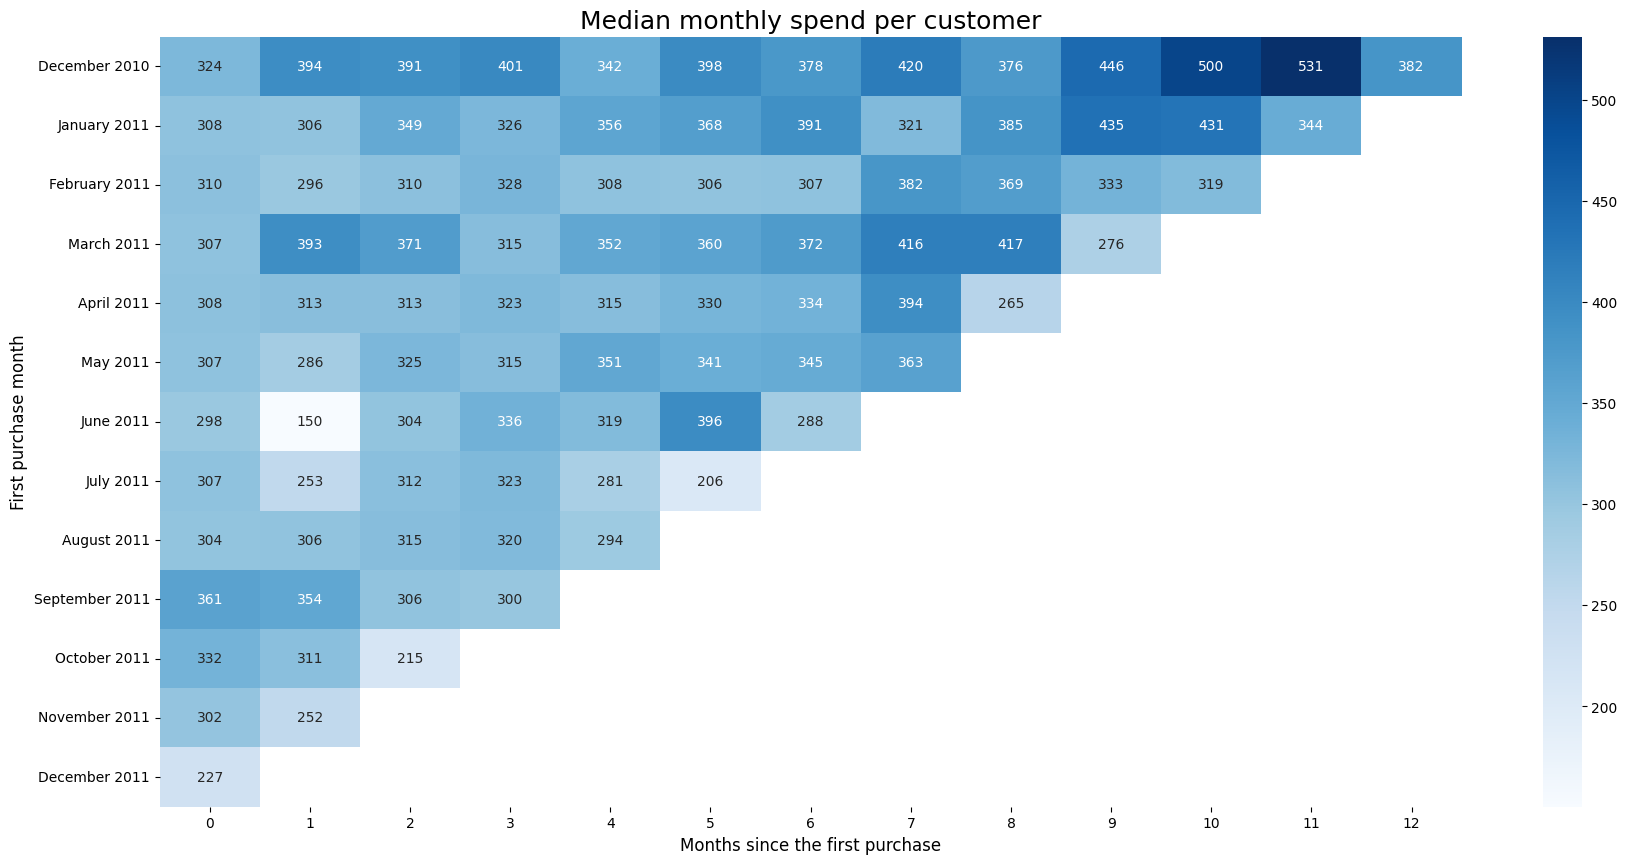

In [ ]:
cohort_month_map = df[["CustomerID", "CohortMonth"]].drop_duplicates(
    subset="CustomerID", keep="first"
)
aov_heatmap = (
    df.groupby(["CustomerID", "CohortIndex"])
    .agg(SpendingInMonth=("TotalPrice", "sum"))
    .reset_index()
    .merge(cohort_month_map, left_on="CustomerID", right_on="CustomerID")
    .pivot_table(
        columns="CohortIndex",
        index="CohortMonth",
        values="SpendingInMonth",
        aggfunc="median",
    )
)
plt.figure(figsize=(21, 10))
sns.heatmap(aov_heatmap, annot=True, cmap="Blues", fmt=".0f", yticklabels=y_labels)
plt.title("Median monthly spend per customer", fontsize=18)
plt.ylabel("First purchase month", fontsize=12)
plt.xlabel("Months since the first purchase", fontsize=12)